In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import DistilBertModel, DistilBertTokenizer
from transformers import CLIPModel
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from PIL import Image
import timm
from peft import LoraConfig, get_peft_model
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df = pd.read_pickle('dish_dataset.pkl')
df.head()

,dish_id,total_calories,total_mass,total_fat,total_carb,total_protein,ingredients,rgb_image_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,"soy sauce, garlic, white rice, parsley, onions...",data/overhead/dish_1561662216/rgb.png
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,"pepper, white rice, mixed greens, garlic, soy ...",data/overhead/dish_1561662054/rgb.png
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,"jalapenos, lemon juice, pork, wheat berry, cab...",data/overhead/dish_1562008979/rgb.png
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,"cherry tomatoes, cucumbers, baby carrots",data/overhead/dish_1560455030/rgb.png
5,dish_1558372433,74.360001,143.0,0.286000,0.429000,20.020000,deprecated,data/overhead/dish_1558372433/rgb.png


In [4]:
class DishDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['rgb_image_path']
        image = Image.open(img_path).convert('RGB').copy()
        if self.transform:
            image = self.transform(image)
        
        # Targets: total_calories, total_mass, total_fat, total_carb, total_protein
        targets = torch.tensor([
            row['total_calories'],
            row['total_mass'],
            row['total_fat'],
            row['total_carb'],
            row['total_protein']
        ], dtype=torch.float32)
        
        return image, targets

# Define transforms
train_transform = transforms.Compose([
    
    transforms.RandomResizedCrop(
        224,
        scale=(0.6, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomAffine(
        degrees=20,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25,
        hue=0.05
    ),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.08)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split data
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Create datasets
train_dataset = DishDataset(train_df, transform=train_transform)
val_dataset = DishDataset(val_df, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Increased from 16
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [5]:
class DeiTRegressor(nn.Module):
    def __init__(self, n_outputs):
        super().__init__()
        

        self.backbone = timm.create_model(
            "deit_tiny_patch16_224",
            pretrained=True,
            num_classes=0
        )
        
        embed_dim = self.backbone.num_features  # 192
        
        # Custom regression head - reduced size to prevent overfitting
        self.regression_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),  # Reduced from 256
            nn.GELU(),
            nn.Dropout(0.5),  # Increased from 0.2
            nn.Linear(128, n_outputs)
        )
    
    def forward(self, x):
        features = self.backbone(x)  # [B, 192]
        output = self.regression_head(features)  # [B, n_outputs]
        return output

In [6]:
def build_frozen_model(n_outputs, device):
    model = DeiTRegressor(n_outputs).to(device)
    
    # Freeze backbone
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    optimizer = torch.optim.AdamW(
        model.regression_head.parameters(),
        lr=1e-4, 
        weight_decay=5e-4
    )
    
    return model, optimizer

def build_full_finetune_model(n_outputs, device):
    model = DeiTRegressor(n_outputs).to(device)
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=5e-5,  # Reduced from 1e-4 for slower, more stable learning
        weight_decay=5e-4  # Increased from 1e-4 for stronger regularization
    )
    
    return model, optimizer

def build_lora_model(n_outputs, device):
    model = DeiTRegressor(n_outputs).to(device)
    
    # Freeze backbone first
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    # Configure LoRA with reduced capacity
    lora_config = LoraConfig(
        r=4,  # Reduced from 8 to limit adapters
        lora_alpha=8,  # Reduced from 16 (alpha=r is less aggressive)
        target_modules=["qkv"],  # attention projections
        lora_dropout=0.3,  # Increased from 0.1 for better regularization
        bias="none"
    )
    
    # Inject LoRA into backbone
    model.backbone = get_peft_model(model.backbone, lora_config)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-4,  # Reduced from 5e-4 for slower adaptation
        weight_decay=5e-4  # Increased from 1e-4 for stronger regularization
    )
    
    return model, optimizer

In [7]:
def train(model, optimizer, train_loader, val_loader, device, epochs, normalize_targets=True, patience=5):
    """
    Training loop with detailed loss reporting and early stopping.
    
    Args:
        normalize_targets: If True, normalizes each target independently
        patience: Stop training if val loss doesn't improve for this many epochs
    
    Returns:
        Dictionary containing:
        - train_losses: list of average training losses per epoch
        - val_losses: list of average validation losses per epoch
        - val_maes: dict mapping output names to lists of MAE values per epoch
    """
    output_names = ['total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein']
    criterion = nn.SmoothL1Loss(reduction='none')  # Per-element loss
    
    # Initialize metrics tracking
    train_losses = []
    val_losses = []
    val_maes_per_output = {name: [] for name in output_names}
    
    # Compute normalization factors from training data
    if normalize_targets:
        targets_all = torch.cat([targets for _, targets in train_loader], dim=0)
        targets_mean = targets_all.mean(dim=0)
        targets_std = targets_all.std(dim=0) + 1e-8  # avoid division by zero
        targets_mean = targets_mean.to(device)
        targets_std = targets_std.to(device)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # ===== TRAINING =====
        model.train()
        losses_per_output = [0.0] * 5  # Loss for each of 5 outputs
        
        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device).float()
            
            # Normalize targets for balanced loss
            if normalize_targets:
                targets_norm = (targets - targets_mean) / targets_std
            else:
                targets_norm = targets
            
            optimizer.zero_grad()
            outputs = model(images)  # [B, 5]
            
            # Compute per-output loss (in normalized space)
            loss_per_output = criterion(outputs, targets_norm).mean(dim=0)  # [5]
            
            # Denormalize predictions to show actual errors
            outputs_denorm = outputs * targets_std + targets_mean
            mae_per_output = torch.abs(outputs_denorm - targets).mean(dim=0)  # [5] MAE in original units
            
            # Total loss (average across 5 outputs)
            loss = loss_per_output.mean()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Track loss per output
            for i in range(5):
                losses_per_output[i] += loss_per_output[i].item()
        
        avg_losses = [l / len(train_loader) for l in losses_per_output]
        avg_train_loss = sum(avg_losses) / 5
        train_losses.append(avg_train_loss)
        
        # ===== VALIDATION =====
        model.eval()
        val_losses_per_output = [0.0] * 5
        val_mae_per_output = [0.0] * 5
        
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device).float()
                
                if normalize_targets:
                    targets_norm = (targets - targets_mean) / targets_std
                else:
                    targets_norm = targets
                
                outputs = model(images)
                loss_per_output = criterion(outputs, targets_norm).mean(dim=0)
                outputs_denorm = outputs * targets_std + targets_mean
                mae_per_output = torch.abs(outputs_denorm - targets).mean(dim=0)
                
                for i in range(5):
                    val_losses_per_output[i] += loss_per_output[i].item()
                    val_mae_per_output[i] += mae_per_output[i].item()
        
        val_avg_losses = [l / len(val_loader) for l in val_losses_per_output]
        val_avg_mae = [l / len(val_loader) for l in val_mae_per_output]
        val_avg_loss = sum(val_avg_losses) / 5
        val_losses.append(val_avg_loss)
        
        # Store per-output MAE values
        for i, name in enumerate(output_names):
            val_maes_per_output[name].append(val_avg_mae[i])
        
        # Early stopping: check if validation loss improved
        overfitting_gap = val_avg_loss - avg_train_loss
        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Print epoch results with per-output breakdown
        gap_indicator = " ⚠️ OVERFITTING" if overfitting_gap > 0.03 else ""
        print(f"\nEpoch {epoch+1}/{epochs}{gap_indicator} [Patience: {patience_counter}/{patience}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_avg_loss:.4f} | Gap: {overfitting_gap:.4f}")
        print("Val MAE per output:")
        for i, name in enumerate(output_names):
            print(f"  {name}: {val_avg_mae[i]:.4f}", end="  ")
        print()
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered after {epoch+1} epochs (patience={patience})")
            break
    
    # Return metrics for plotting
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_maes': val_maes_per_output
    }


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
n_outputs = 5

# 1️⃣ Frozen
model_frozen, opt_frozen = build_frozen_model(n_outputs, device)

# 2️⃣ Full fine-tune
model_full, opt_full = build_full_finetune_model(n_outputs, device)

# 3️⃣ LoRA
model_lora, opt_lora = build_lora_model(n_outputs, device)

In [9]:
metrics_frozen = train(model_frozen, opt_frozen, train_loader, val_loader, device, epochs=10)



Epoch 1/10 [Patience: 0/5]
Train Loss: 0.3378 | Val Loss: 0.2787 | Gap: -0.0591
Val MAE per output:
  total_calories: 139.0189    total_mass: 92.4958    total_fat: 9.4635    total_carb: 11.3438    total_protein: 12.2216  

Epoch 2/10 [Patience: 0/5]
Train Loss: 0.2834 | Val Loss: 0.2454 | Gap: -0.0380
Val MAE per output:
  total_calories: 125.9083    total_mass: 79.7878    total_fat: 8.6511    total_carb: 10.5947    total_protein: 10.9699  

Epoch 3/10 [Patience: 0/5]
Train Loss: 0.2562 | Val Loss: 0.2278 | Gap: -0.0284
Val MAE per output:
  total_calories: 119.5840    total_mass: 73.5587    total_fat: 8.0908    total_carb: 10.1038    total_protein: 10.3385  

Epoch 4/10 [Patience: 0/5]
Train Loss: 0.2366 | Val Loss: 0.2182 | Gap: -0.0183
Val MAE per output:
  total_calories: 115.1844    total_mass: 70.6913    total_fat: 7.8433    total_carb: 9.7766    total_protein: 9.9725  

Epoch 5/10 [Patience: 0/5]
Train Loss: 0.2298 | Val Loss: 0.2080 | Gap: -0.0218
Val MAE per output:
  total_c

In [10]:
metrics_full = train(model_full, opt_full, train_loader, val_loader, device, epochs=10)



Epoch 1/10 [Patience: 0/5]
Train Loss: 0.2380 | Val Loss: 0.1617 | Gap: -0.0764
Val MAE per output:
  total_calories: 85.4707    total_mass: 57.9115    total_fat: 6.7689    total_carb: 8.5632    total_protein: 8.4132  

Epoch 2/10 [Patience: 0/5]
Train Loss: 0.1730 | Val Loss: 0.1513 | Gap: -0.0217
Val MAE per output:
  total_calories: 77.4830    total_mass: 61.6397    total_fat: 6.3042    total_carb: 7.9103    total_protein: 7.8243  

Epoch 3/10 [Patience: 1/5]
Train Loss: 0.1584 | Val Loss: 0.1579 | Gap: -0.0004
Val MAE per output:
  total_calories: 78.8075    total_mass: 71.5417    total_fat: 5.7713    total_carb: 7.8183    total_protein: 7.3656  

Epoch 4/10 [Patience: 0/5]
Train Loss: 0.1392 | Val Loss: 0.1201 | Gap: -0.0191
Val MAE per output:
  total_calories: 70.8562    total_mass: 53.5382    total_fat: 5.7290    total_carb: 7.0628    total_protein: 7.1461  

Epoch 5/10 ⚠️ OVERFITTING [Patience: 1/5]
Train Loss: 0.1333 | Val Loss: 0.1702 | Gap: 0.0368
Val MAE per output:
  tot

In [11]:
metrics_lora = train(model_lora, opt_lora, train_loader, val_loader, device, epochs=10)



Epoch 1/10 [Patience: 0/5]
Train Loss: 0.2946 | Val Loss: 0.2184 | Gap: -0.0762
Val MAE per output:
  total_calories: 116.1376    total_mass: 70.7271    total_fat: 7.7941    total_carb: 10.2042    total_protein: 10.3576  

Epoch 2/10 [Patience: 0/5]
Train Loss: 0.2134 | Val Loss: 0.1799 | Gap: -0.0336
Val MAE per output:
  total_calories: 96.3936    total_mass: 59.9408    total_fat: 7.0961    total_carb: 9.0135    total_protein: 9.0361  

Epoch 3/10 [Patience: 0/5]
Train Loss: 0.1870 | Val Loss: 0.1707 | Gap: -0.0163
Val MAE per output:
  total_calories: 92.6293    total_mass: 60.2997    total_fat: 6.8135    total_carb: 8.6152    total_protein: 8.3106  

Epoch 4/10 [Patience: 0/5]
Train Loss: 0.1765 | Val Loss: 0.1579 | Gap: -0.0186
Val MAE per output:
  total_calories: 87.3388    total_mass: 57.1039    total_fat: 6.5864    total_carb: 8.2897    total_protein: 7.9078  

Epoch 5/10 [Patience: 0/5]
Train Loss: 0.1629 | Val Loss: 0.1531 | Gap: -0.0098
Val MAE per output:
  total_calories

In [14]:
def plot_training_comparison(**models_metrics):
    """
    Plot training curves comparing multiple models.
    
    Args:
        **models_metrics: Keyword arguments where keys are model names and 
                         values are metrics dicts returned from train() function.
                         Each metrics dict contains:
                         - 'train_losses': list of training losses per epoch
                         - 'val_losses': list of validation losses per epoch
                         - 'val_maes': dict mapping output names to MAE lists
    """
    output_names = ['total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # Create figure with 8 subplots (4x2): 2 for losses, 5 for MAE per output, 1 unused
    fig, axes = plt.subplots(4, 2, figsize=(16, 16))
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # ===== Plot 1: Training Loss Comparison =====
    ax = axes_flat[0]
    for (model_name, metrics), color in zip(models_metrics.items(), colors):
        epochs = range(1, len(metrics['train_losses']) + 1)
        ax.plot(epochs, metrics['train_losses'], marker='o', label=model_name, 
                color=color, linewidth=2, markersize=5)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)
    ax.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # ===== Plot 2: Validation Loss Comparison =====
    ax = axes_flat[1]
    for (model_name, metrics), color in zip(models_metrics.items(), colors):
        epochs = range(1, len(metrics['val_losses']) + 1)
        ax.plot(epochs, metrics['val_losses'], marker='s', label=model_name, 
                color=color, linewidth=2, markersize=5)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Validation Loss', fontsize=11)
    ax.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # ===== Plot 3-7: MAE for Each Nutrition Output =====
    for output_idx, output_name in enumerate(output_names):
        ax = axes_flat[2 + output_idx]
        
        for (model_name, metrics), color in zip(models_metrics.items(), colors):
            mae_values = metrics['val_maes'][output_name]
            epochs = range(1, len(mae_values) + 1)
            ax.plot(epochs, mae_values, marker='^', label=model_name, 
                    color=color, linewidth=2, markersize=5)
        
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(f'MAE ({output_name})', fontsize=11)
        ax.set_title(f'MAE: {output_name.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Hide the last unused subplot
    axes_flat[7].axis('off')
    
    plt.tight_layout()
    plt.show()


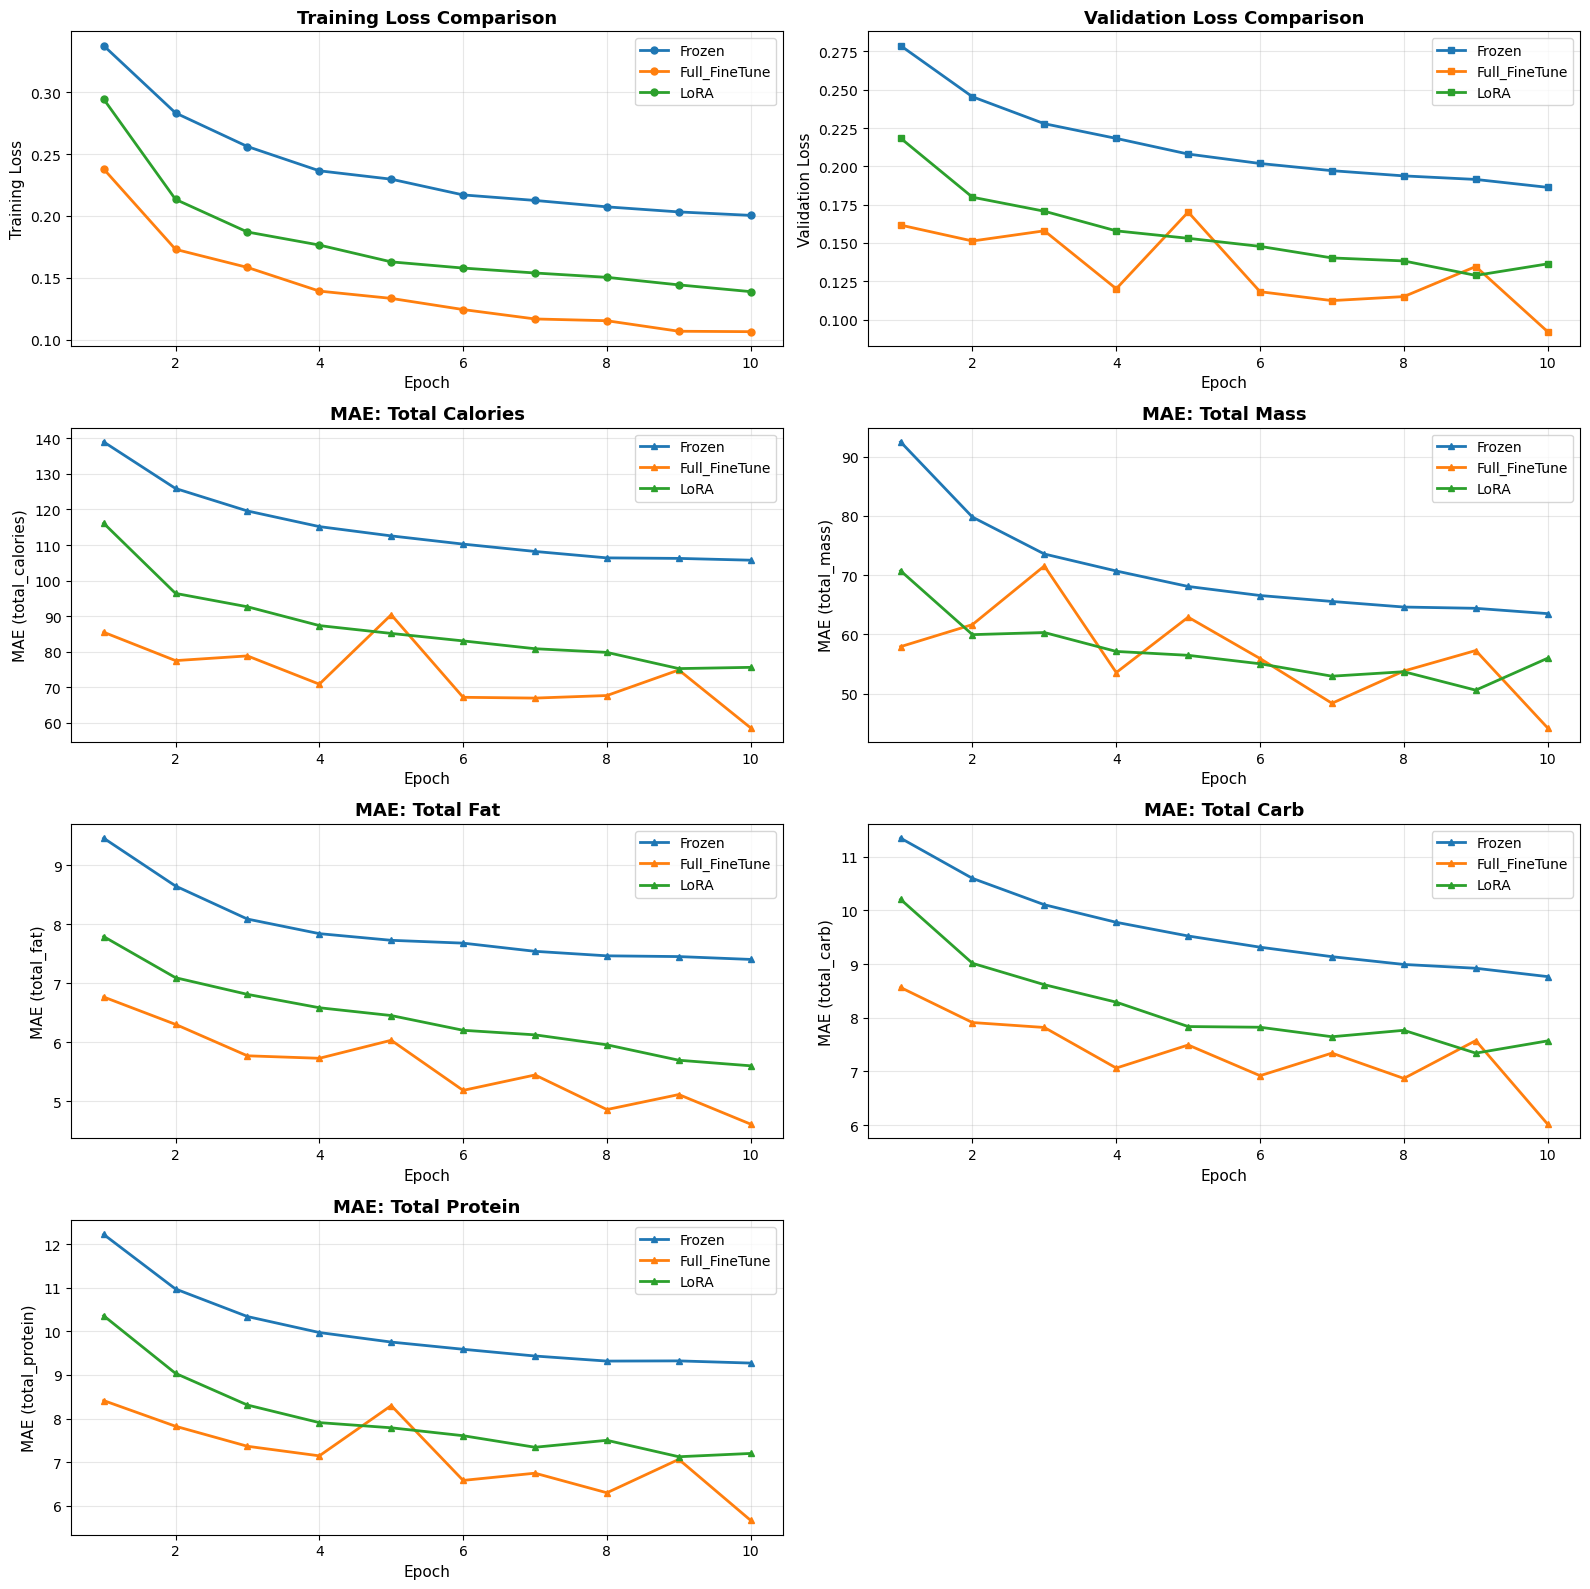

In [15]:
plot_training_comparison(
    Frozen=metrics_frozen,
    Full_FineTune=metrics_full,
    LoRA=metrics_lora
)


### Multimodal architecture (with ingredients)

In [20]:
class MultiModalNutritionModel(nn.Module):
    
    def __init__(self, n_outputs):
        super().__init__()

        # IMAGE BACKBONE
        self.image_encoder = timm.create_model(
            "deit_tiny_patch16_224",
            pretrained=True,
            num_classes=0
        )

        image_dim = self.image_encoder.num_features  # 192

        # TEXT BACKBONE
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        text_dim = 768

        # Freeze most of the encoders
        for param in self.image_encoder.parameters():
            param.requires_grad = False

        for param in self.text_encoder.parameters():
            param.requires_grad = False

        # FUSION HEAD
        fusion_dim = image_dim + text_dim

        self.regressor = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, n_outputs)
        )

    def forward(self, image, input_ids, attention_mask):

        # Image features
        image_features = self.image_encoder(image)

        # Text features
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = text_outputs.last_hidden_state[:,0,:]  # CLS token

        # Fusion
        combined = torch.cat([image_features, text_features], dim=1)

        outputs = self.regressor(combined)

        return outputs

In [16]:
# Multimodal dataset: returns image + raw ingredient sentence + nutrition targets
class MultiModalDishDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row['rgb_image_path']
        image = Image.open(img_path).convert('RGB').copy()
        if self.transform:
            image = self.transform(image)

        ingredients_raw = row.get('ingredients', '')
        if pd.isna(ingredients_raw):
            ingredients_raw = ''
        ingredients_raw = str(ingredients_raw).strip()
        ingredient_sentence = (
            f"The ingredients are: {ingredients_raw}"
            if ingredients_raw else
            "The ingredients are: unknown"
        )

        targets = torch.tensor([
            row['total_calories'],
            row['total_mass'],
            row['total_fat'],
            row['total_carb'],
            row['total_protein']
        ], dtype=torch.float32)

        return image, ingredient_sentence, targets

In [17]:
# Tokenize ingredient sentences at batch time (not inside dataset)
def make_multimodal_collate_fn(tokenizer, max_length=64):
    def collate_fn(batch):
        images, ingredient_sentences, targets = zip(*batch)

        images = torch.stack(images)
        targets = torch.stack(targets)

        text_batch = tokenizer(
            list(ingredient_sentences),
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        return images, text_batch['input_ids'], text_batch['attention_mask'], targets

    return collate_fn

In [18]:
def train_multimodal(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    epochs,
    normalize_targets=True,
    patience=5
):
    """
    Training loop for multimodal model (image + ingredient sentence).
    """
    output_names = ['total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein']
    criterion = nn.SmoothL1Loss(reduction='none')

    train_losses = []
    val_losses = []
    val_maes_per_output = {name: [] for name in output_names}

    if normalize_targets:
        train_targets = torch.cat([targets for _, _, _, targets in train_loader], dim=0)
        targets_mean = train_targets.mean(dim=0).to(device)
        targets_std = (train_targets.std(dim=0) + 1e-8).to(device)
    else:
        targets_mean = torch.zeros(5, device=device)
        targets_std = torch.ones(5, device=device)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_losses_per_output = [0.0] * 5

        for images, input_ids, attention_mask, targets in train_loader:
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            targets = targets.to(device).float()

            targets_norm = (targets - targets_mean) / targets_std if normalize_targets else targets

            optimizer.zero_grad()
            outputs = model(images, input_ids, attention_mask)

            loss_per_output = criterion(outputs, targets_norm).mean(dim=0)
            loss = loss_per_output.mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            for i in range(5):
                train_losses_per_output[i] += loss_per_output[i].item()

        avg_train_losses = [l / len(train_loader) for l in train_losses_per_output]
        avg_train_loss = sum(avg_train_losses) / 5
        train_losses.append(avg_train_loss)

        model.eval()
        val_losses_per_output = [0.0] * 5
        val_mae_per_output = [0.0] * 5

        with torch.no_grad():
            for images, input_ids, attention_mask, targets in val_loader:
                images = images.to(device)
                input_ids = input_ids.to(device)
                attention_mask = attention_mask.to(device)
                targets = targets.to(device).float()

                targets_norm = (targets - targets_mean) / targets_std if normalize_targets else targets

                outputs = model(images, input_ids, attention_mask)
                loss_per_output = criterion(outputs, targets_norm).mean(dim=0)

                outputs_denorm = outputs * targets_std + targets_mean
                mae_per_output = torch.abs(outputs_denorm - targets).mean(dim=0)

                for i in range(5):
                    val_losses_per_output[i] += loss_per_output[i].item()
                    val_mae_per_output[i] += mae_per_output[i].item()

        val_avg_losses = [l / len(val_loader) for l in val_losses_per_output]
        val_avg_mae = [l / len(val_loader) for l in val_mae_per_output]
        val_avg_loss = sum(val_avg_losses) / 5
        val_losses.append(val_avg_loss)

        for i, name in enumerate(output_names):
            val_maes_per_output[name].append(val_avg_mae[i])

        overfitting_gap = val_avg_loss - avg_train_loss
        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch + 1}/{epochs} [Patience: {patience_counter}/{patience}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_avg_loss:.4f} | Gap: {overfitting_gap:.4f}")
        print("Val MAE per output:")
        for i, name in enumerate(output_names):
            print(f"  {name}: {val_avg_mae[i]:.4f}", end='  ')
        print()

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs (patience={patience})")
            break

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_maes': val_maes_per_output
    }

In [21]:
# Build multimodal loaders and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
multimodal_collate_fn = make_multimodal_collate_fn(tokenizer, max_length=64)

train_dataset_mm = MultiModalDishDataset(train_df, transform=train_transform)
val_dataset_mm = MultiModalDishDataset(val_df, transform=val_transform)

train_loader_mm = DataLoader(
    train_dataset_mm,
    batch_size=32,
    shuffle=True,
    collate_fn=multimodal_collate_fn
)

val_loader_mm = DataLoader(
    val_dataset_mm,
    batch_size=32,
    shuffle=False,
    collate_fn=multimodal_collate_fn
)

model_mm = MultiModalNutritionModel(n_outputs=5).to(device)
optimizer_mm = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_mm.parameters()),
    lr=1e-4,
    weight_decay=5e-4
)

# Quick batch sanity check
images_b, input_ids_b, attention_mask_b, targets_b = next(iter(train_loader_mm))
print('images:', images_b.shape)
print('input_ids:', input_ids_b.shape)
print('attention_mask:', attention_mask_b.shape)
print('targets:', targets_b.shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


images: torch.Size([32, 3, 224, 224])
input_ids: torch.Size([32, 64])
attention_mask: torch.Size([32, 64])
targets: torch.Size([32, 5])


In [22]:
# Train multimodal model
metrics_mm = train_multimodal(
    model=model_mm,
    optimizer=optimizer_mm,
    train_loader=train_loader_mm,
    val_loader=val_loader_mm,
    device=device,
    epochs=10,
    normalize_targets=True,
    patience=5
)


Epoch 1/10 [Patience: 0/5]
Train Loss: 0.2725 | Val Loss: 0.2101 | Gap: -0.0624
Val MAE per output:
  total_calories: 112.1080    total_mass: 66.2389    total_fat: 7.7610    total_carb: 10.0433    total_protein: 9.9083  

Epoch 2/10 [Patience: 0/5]
Train Loss: 0.2035 | Val Loss: 0.1861 | Gap: -0.0174
Val MAE per output:
  total_calories: 99.8263    total_mass: 61.0158    total_fat: 7.1477    total_carb: 8.8345    total_protein: 8.9429  

Epoch 3/10 [Patience: 0/5]
Train Loss: 0.1819 | Val Loss: 0.1664 | Gap: -0.0155
Val MAE per output:
  total_calories: 94.9724    total_mass: 55.8721    total_fat: 6.9319    total_carb: 8.2767    total_protein: 8.5818  

Epoch 4/10 [Patience: 0/5]
Train Loss: 0.1781 | Val Loss: 0.1649 | Gap: -0.0132
Val MAE per output:
  total_calories: 90.3925    total_mass: 57.4942    total_fat: 6.5414    total_carb: 8.2165    total_protein: 8.2681  

Epoch 5/10 [Patience: 0/5]
Train Loss: 0.1709 | Val Loss: 0.1540 | Gap: -0.0169
Val MAE per output:
  total_calories:

### Stage 1: Image -> ingredients and masses (then nutrition via CSV lookup)

In [28]:
import os


def parse_dish_line_full(line):
    parts = [p.strip() for p in line.strip().split(',')]
    if len(parts) < 6:
        return None

    dish_id = parts[0]
    total_calories = float(parts[1])
    total_mass = float(parts[2])
    total_fat = float(parts[3])
    total_carb = float(parts[4])
    total_protein = float(parts[5])

    ingredients = []
    for i in range(6, len(parts), 7):
        if i + 6 >= len(parts):
            break
        ingr_id_str = parts[i]
        ingr_name = parts[i + 1]
        mass = float(parts[i + 2])
        cal = float(parts[i + 3])
        fat = float(parts[i + 4])
        carb = float(parts[i + 5])
        protein = float(parts[i + 6])

        try:
            ingr_id_num = int(ingr_id_str.split('_')[-1])
        except ValueError:
            continue

        ingredients.append({
            'ingr_id': ingr_id_num,
            'name': ingr_name,
            'mass': mass,
            'cal': cal,
            'fat': fat,
            'carb': carb,
            'protein': protein
        })

    return {
        'dish_id': dish_id,
        'rgb_image_path': f"data/overhead/{dish_id}/rgb.png",
        'total_calories': total_calories,
        'total_mass': total_mass,
        'total_fat': total_fat,
        'total_carb': total_carb,
        'total_protein': total_protein,
        'ingredients': ingredients
    }


# Build per-dish structured records with ingredient IDs + masses
raw_records = []
source_csvs = [
    'data/dishes_metadata/dish_metadata_cafe1.csv'
]

for csv_path in source_csvs:
    with open(csv_path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            rec = parse_dish_line_full(line)
            if rec is None:
                continue
            if os.path.exists(rec['rgb_image_path']):
                raw_records.append(rec)

# Keep train/val split aligned with your previous split when possible
train_ids = set(train_df['dish_id'].astype(str).tolist())
val_ids = set(val_df['dish_id'].astype(str).tolist())

train_records = [r for r in raw_records if r['dish_id'] in train_ids]
val_records = [r for r in raw_records if r['dish_id'] in val_ids]

if len(train_records) == 0 or len(val_records) == 0:
    split_idx = int(0.8 * len(raw_records))
    train_records = raw_records[:split_idx]
    val_records = raw_records[split_idx:]

# Ingredient vocabulary from observed data
ingredient_ids = sorted({ing['ingr_id'] for r in raw_records for ing in r['ingredients']})
ingr_id_to_idx = {ingr_id: i for i, ingr_id in enumerate(ingredient_ids)}
num_ingredients = len(ingredient_ids)

# Load per-gram nutrition table (used for lookup reconstruction)
ingr_meta = pd.read_csv('data/dishes_metadata/ingredients_metadata.csv')
ingr_nutri_per_g = {}
for _, row in ingr_meta.iterrows():
    ingr_nutri_per_g[int(row['id'])] = np.array([
        row['cal/g'],
        row['fat(g)'],
        row['carb(g)'],
        row['protein(g)']
    ], dtype=np.float32)

nutri_lookup_matrix_np = np.zeros((num_ingredients, 4), dtype=np.float32)
for ingr_id, idx in ingr_id_to_idx.items():
    if ingr_id in ingr_nutri_per_g:
        nutri_lookup_matrix_np[idx] = ingr_nutri_per_g[ingr_id]

print('Structured records:', len(raw_records))
print('Train records:', len(train_records), '| Val records:', len(val_records))
print('Ingredient vocabulary size:', num_ingredients)

Structured records: 3262
Train records: 2610 | Val records: 652
Ingredient vocabulary size: 200


In [29]:
class IngredientMassDataset(Dataset):
    def __init__(self, records, ingr_id_to_idx, transform=None):
        self.records = records
        self.ingr_id_to_idx = ingr_id_to_idx
        self.transform = transform
        self.num_ingredients = len(ingr_id_to_idx)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        image = Image.open(rec['rgb_image_path']).convert('RGB').copy()
        if self.transform:
            image = self.transform(image)

        presence = torch.zeros(self.num_ingredients, dtype=torch.float32)
        masses = torch.zeros(self.num_ingredients, dtype=torch.float32)

        for ing in rec['ingredients']:
            ing_idx = self.ingr_id_to_idx.get(ing['ingr_id'])
            if ing_idx is None:
                continue
            presence[ing_idx] = 1.0
            masses[ing_idx] += float(ing['mass'])

        targets = torch.tensor([
            rec['total_calories'],
            rec['total_mass'],
            rec['total_fat'],
            rec['total_carb'],
            rec['total_protein']
        ], dtype=torch.float32)

        return image, presence, masses, targets


class IngredientMassPredictor(nn.Module):
    def __init__(self, num_ingredients, freeze_backbone=True):
        super().__init__()
        self.backbone = timm.create_model(
            'deit_tiny_patch16_224',
            pretrained=True,
            num_classes=0
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        embed_dim = self.backbone.num_features

        self.shared_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        self.presence_head = nn.Linear(256, num_ingredients)
        self.mass_head = nn.Linear(256, num_ingredients)

    def forward(self, x):
        features = self.backbone(x)
        hidden = self.shared_head(features)
        presence_logits = self.presence_head(hidden)
        mass_pred = torch.nn.functional.softplus(self.mass_head(hidden))
        return presence_logits, mass_pred


def masses_to_nutrients(masses, lookup_matrix):
    """
    masses: [B, N], lookup_matrix: [N, 4] with [cal/g, fat/g, carb/g, protein/g]
    returns [B, 4]
    """
    return masses @ lookup_matrix

In [30]:
def train_ingredient_mass_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    lookup_matrix,
    device,
    epochs=10,
    alpha_presence=1.0,
    alpha_mass=1.0,
    alpha_nutri=0.2,
    patience=5
):
    bce = nn.BCEWithLogitsLoss()
    smooth_l1 = nn.SmoothL1Loss()

    train_losses = []
    val_losses = []
    val_maes = {
        'total_calories': [],
        'total_mass': [],
        'total_fat': [],
        'total_carb': [],
        'total_protein': []
    }

    best_val = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, presence_true, mass_true, targets in train_loader:
            images = images.to(device)
            presence_true = presence_true.to(device)
            mass_true = mass_true.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            presence_logits, mass_pred = model(images)

            presence_loss = bce(presence_logits, presence_true)

            mass_mask = presence_true
            denom = mass_mask.sum().clamp(min=1.0)
            mass_loss = (torch.abs(mass_pred - mass_true) * mass_mask).sum() / denom

            pred_nutrients = masses_to_nutrients(mass_pred, lookup_matrix)
            true_nutrients = torch.stack([
                targets[:, 0],
                targets[:, 2],
                targets[:, 3],
                targets[:, 4]
            ], dim=1)
            nutrient_loss = smooth_l1(pred_nutrients, true_nutrients)

            loss = (
                alpha_presence * presence_loss +
                alpha_mass * mass_loss +
                alpha_nutri * nutrient_loss
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_running = 0.0
        mae_totals = torch.zeros(5, device=device)

        with torch.no_grad():
            for images, presence_true, mass_true, targets in val_loader:
                images = images.to(device)
                presence_true = presence_true.to(device)
                mass_true = mass_true.to(device)
                targets = targets.to(device)

                presence_logits, mass_pred = model(images)

                presence_loss = bce(presence_logits, presence_true)
                mass_mask = presence_true
                denom = mass_mask.sum().clamp(min=1.0)
                mass_loss = (torch.abs(mass_pred - mass_true) * mass_mask).sum() / denom

                pred_nutrients = masses_to_nutrients(mass_pred, lookup_matrix)
                true_nutrients = torch.stack([
                    targets[:, 0],
                    targets[:, 2],
                    targets[:, 3],
                    targets[:, 4]
                ], dim=1)
                nutrient_loss = smooth_l1(pred_nutrients, true_nutrients)

                val_loss = (
                    alpha_presence * presence_loss +
                    alpha_mass * mass_loss +
                    alpha_nutri * nutrient_loss
                )
                val_running += val_loss.item()

                pred_totals = torch.stack([
                    pred_nutrients[:, 0],
                    mass_pred.sum(dim=1),
                    pred_nutrients[:, 1],
                    pred_nutrients[:, 2],
                    pred_nutrients[:, 3]
                ], dim=1)

                mae_totals += torch.abs(pred_totals - targets).mean(dim=0)

        avg_val_loss = val_running / len(val_loader)
        val_losses.append(avg_val_loss)

        mae_totals = mae_totals / len(val_loader)
        val_maes['total_calories'].append(mae_totals[0].item())
        val_maes['total_mass'].append(mae_totals[1].item())
        val_maes['total_fat'].append(mae_totals[2].item())
        val_maes['total_carb'].append(mae_totals[3].item())
        val_maes['total_protein'].append(mae_totals[4].item())

        print(f"\nEpoch {epoch + 1}/{epochs} [Patience: {patience_counter}/{patience}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(
            f"MAE -> cal: {val_maes['total_calories'][-1]:.2f}, "
            f"mass: {val_maes['total_mass'][-1]:.2f}, "
            f"fat: {val_maes['total_fat'][-1]:.2f}, "
            f"carb: {val_maes['total_carb'][-1]:.2f}, "
            f"protein: {val_maes['total_protein'][-1]:.2f}"
        )

        if avg_val_loss < best_val:
            best_val = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_maes': val_maes
    }

In [31]:
# Build Stage-1 loaders/model and run a short smoke training
train_dataset_stage1 = IngredientMassDataset(train_records, ingr_id_to_idx, transform=train_transform)
val_dataset_stage1 = IngredientMassDataset(val_records, ingr_id_to_idx, transform=val_transform)

train_loader_stage1 = DataLoader(train_dataset_stage1, batch_size=32, shuffle=True)
val_loader_stage1 = DataLoader(val_dataset_stage1, batch_size=32, shuffle=False)

model_stage1 = IngredientMassPredictor(num_ingredients=num_ingredients, freeze_backbone=True).to(device)
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_stage1.parameters()),
    lr=1e-4,
    weight_decay=5e-4
)

lookup_matrix_t = torch.tensor(nutri_lookup_matrix_np, dtype=torch.float32, device=device)

# Quick tensor sanity check
sample_batch = next(iter(train_loader_stage1))
print('image batch:', sample_batch[0].shape)
print('presence batch:', sample_batch[1].shape)
print('mass batch:', sample_batch[2].shape)
print('targets batch:', sample_batch[3].shape)

# Smoke run (set to 10+ once validated)
metrics_stage1 = train_ingredient_mass_model(
    model=model_stage1,
    optimizer=optimizer_stage1,
    train_loader=train_loader_stage1,
    val_loader=val_loader_stage1,
    lookup_matrix=lookup_matrix_t,
    device=device,
    epochs=10,
    alpha_presence=1.0,
    alpha_mass=1.0,
    alpha_nutri=0.2,
    patience=3
)

image batch: torch.Size([32, 3, 224, 224])
presence batch: torch.Size([32, 200])
mass batch: torch.Size([32, 200])
targets batch: torch.Size([32, 5])

Epoch 1/10 [Patience: 0/3]
Train Loss: 39.4783 | Val Loss: 39.6412
MAE -> cal: 148.90, mass: 110.78, fat: 9.61, carb: 12.68, protein: 13.20

Epoch 2/10 [Patience: 0/3]
Train Loss: 37.7900 | Val Loss: 37.7946
MAE -> cal: 124.68, mass: 95.03, fat: 8.59, carb: 11.52, protein: 12.01

Epoch 3/10 [Patience: 0/3]
Train Loss: 36.1229 | Val Loss: 36.9084
MAE -> cal: 117.12, mass: 84.12, fat: 8.21, carb: 11.02, protein: 11.33

Epoch 4/10 [Patience: 0/3]
Train Loss: 35.5083 | Val Loss: 36.2162
MAE -> cal: 112.16, mass: 78.45, fat: 8.03, carb: 10.89, protein: 10.79

Epoch 5/10 [Patience: 0/3]
Train Loss: 34.9963 | Val Loss: 35.9347
MAE -> cal: 112.95, mass: 80.33, fat: 7.96, carb: 10.74, protein: 10.65

Epoch 6/10 [Patience: 0/3]
Train Loss: 34.6416 | Val Loss: 35.5046
MAE -> cal: 110.67, mass: 87.93, fat: 7.89, carb: 10.80, protein: 10.39

Epoch 7/